# 04 — Model validation

The three questions every model validator asks:

| Question | Tests |
|---|---|
| **Discrimination** — does it rank risk correctly? | AUC, Gini, KS, rank ordering |
| **Calibration** — is the PD level right? | calibration plot, Brier, Hosmer–Lemeshow, binomial test per grade |
| **Stability** — has the population moved? | PSI on the score, CSI per feature |

Most attention goes to the **out-of-time (OOT)** sample.

In [1]:
import os, sys, pickle
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pdmodel import config as C
pd.set_option("display.float_format", "{:.4f}".format)
PROC = ROOT / "data" / "processed"
from pdmodel import plots, validation as V

In [2]:
S = pd.read_pickle(PROC / "samples.pkl")
binner = pd.read_pickle(PROC / "binner.pkl")
M = pd.read_pickle(PROC / "model.pkl")
card, final = M["scorecard"], M["features"]
y  = {k: v["default"].to_numpy() for k, v in S.items()}
pd_ = {k: card.predict_pd(v) for k, v in S.items()}
sc = {k: card.score(v) for k, v in S.items()}

## 1. Discrimination

In [3]:
disc = pd.DataFrame({k: V.discrimination(y[k], pd_[k]) for k in S}).T
disc["lc_subgrade_gini"] = [2 * V.benchmark_auc(y[k], S[k][C.BENCHMARK_COLUMN]) - 1 for k in S]
disc["rag"] = disc["gini"].map(V.rag_gini)
disc

,auc,gini,ks,lc_subgrade_gini,rag
train,0.6579,0.3157,0.2274,0.2838,AMBER
test,0.6524,0.3047,0.2215,0.2743,AMBER
oot,0.6468,0.2936,0.2109,0.3425,RED


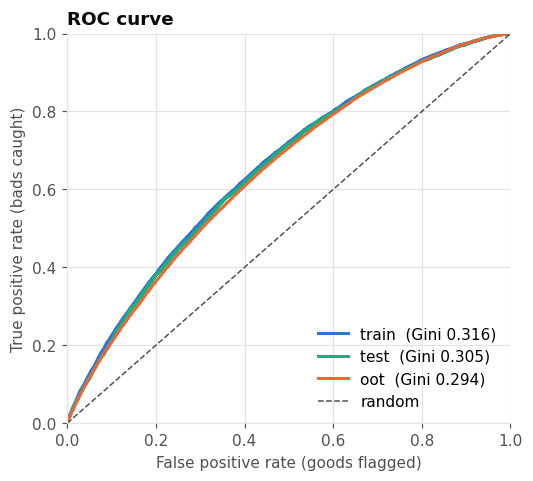

In [4]:
plots.roc_plot({k: (y[k], pd_[k]) for k in S}); plt.show()

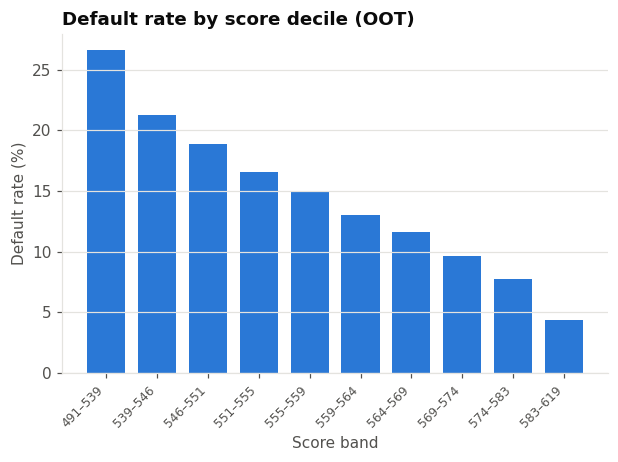

,min_score,max_score,n,bads,bad_rate,monotonic
band,,,,,,
1,491.7320,539.7742,44560,11855,0.2660,True
2,539.7744,546.3596,44560,9488,0.2129,True
3,546.3599,551.3798,44559,8404,0.1886,True
4,551.3798,555.7735,44560,7386,0.1658,True
5,555.7736,559.9964,44559,6668,0.1496,True
6,559.9964,564.3654,44560,5800,0.1302,True
7,564.3656,569.0877,44559,5170,0.1160,True
8,569.0878,574.8531,44560,4287,0.0962,True
9,574.8533,583.4251,44559,3456,0.0776,True


In [5]:
rank = V.rank_ordering(y["oot"], sc["oot"])
plots.bad_rate_by_band(rank, title="Default rate by score decile (OOT)"); plt.show()
rank

**Benchmark:** `lc_subgrade_gini` is how well LendingClub's own grade ranks the same loans.
LendingClub's grade used extra information (their full bureau pull), so matching it with a
handful of public features is a good result; beating it would be surprising — check for leakage.

## 2. Calibration

In [6]:
cal = pd.DataFrame({k: V.calibration_summary(y[k], pd_[k]) for k in S}).T
cal

,mean_pd,observed_dr,brier,hl_chi2,hl_pvalue
train,0.1263,0.1263,0.1065,13.3270,0.1011
test,0.1261,0.1263,0.1069,17.1686,0.0284
oot,0.1273,0.1446,0.1200,1421.7052,0.0000


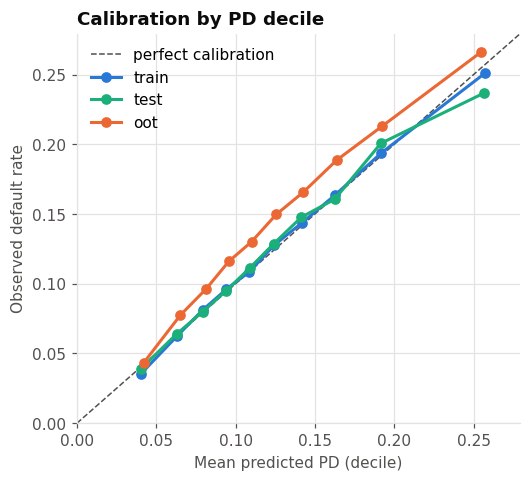

In [7]:
plots.calibration_plot({k: V.calibration_table(y[k], pd_[k]) for k in S}); plt.show()

### Binomial test per rating grade
Grades are 7 equal-population score bands defined on train (grade 1 = best). For each grade we test
H0: true PD ≤ predicted PD. A red grade means the model **under-estimates** risk there.

In [8]:
edges = V.grade_edges(sc["train"])
V.binomial_test_by_grade(y["oot"], pd_["oot"], V.assign_grade(sc["oot"], edges))

,n,defaults,mean_pd,observed_dr,p_value,result
grade,,,,,,
1,58224,2871,0.0461,0.0493,0.0001,RED: PD too low
2,63123,5554,0.0738,0.0880,0.0000,RED: PD too low
3,65223,7448,0.0951,0.1142,0.0000,RED: PD too low
4,64561,8917,0.1164,0.1381,0.0000,RED: PD too low
5,65382,10708,0.1405,0.1638,0.0000,RED: PD too low
6,64868,12756,0.1724,0.1966,0.0000,RED: PD too low
7,64215,16193,0.2386,0.2522,0.0000,RED: PD too low


If OOT grades fail but rank ordering is fine, the problem is the **level**, not the ranking —
the usual fix is recalibration (re-estimate the intercept on recent vintages), not a full rebuild.

## 3. Stability

Score PSI train->test: 0.0001  (GREEN)
Score PSI train->OOT : 0.0015  (GREEN)


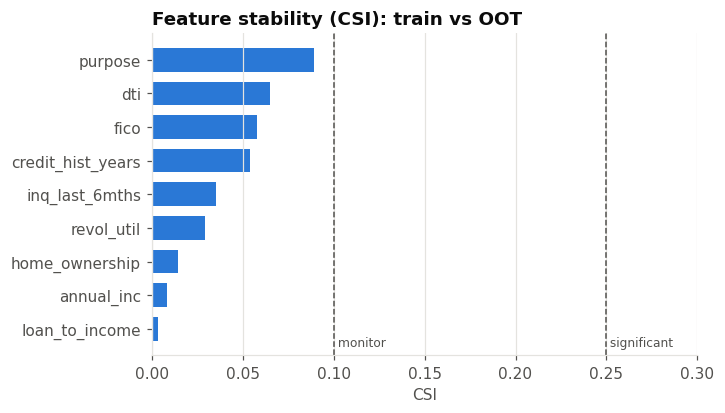

purpose             0.0889
dti                 0.0651
fico                0.0577
credit_hist_years   0.0539
inq_last_6mths      0.0354
revol_util          0.0291
home_ownership      0.0145
annual_inc          0.0085
loan_to_income      0.0033
Name: csi, dtype: float64

In [9]:
print(f"Score PSI train->test: {V.psi(sc['train'], sc['test']):.4f}  ({V.rag_psi(V.psi(sc['train'], sc['test']))})")
print(f"Score PSI train->OOT : {V.psi(sc['train'], sc['oot']):.4f}  ({V.rag_psi(V.psi(sc['train'], sc['oot']))})")
csi = V.csi_by_feature(binner, S["train"], S["oot"], final)
plots.psi_bar(csi); plt.show()
csi

## 4. Write it up
Run `python scripts/run_pipeline.py` to regenerate every table and figure and the
auto-filled `reports/validation_report.md`. Then write the ✍️ commentary sections yourself —
**that write-up is the part interviewers will ask about.**

## ✍️ Interview prep
1. Gini is fine OOT but the binomial test fails in every grade. What's going on and what do you recommend?
2. Why is Hosmer–Lemeshow almost useless with 500k loans?
3. Score PSI is 0.08 but one feature has CSI 0.3. Is the model OK?
4. What would an ongoing monitoring plan for this model look like?